# RQ4: Drift Detection

Kaggle-ready notebook. It auto-detects `AirQualityUCI.csv` and `energydata_complete.csv` / `KAG_energydata_complete.csv`, then saves result tables as CSV and figures as PDF in `/kaggle/working/`.


Air Quality path: /kaggle/input/datasets/primnatoms/airqualityuci/AirQualityUCI.csv
Energy path: /kaggle/input/datasets/primnatoms/energydata-complete/KAG_energydata_complete.csv

Dataset: Air Quality, Target: CO(GT), Shape: (5993, 96)

Dataset: Appliances Energy, Target: Appliances, Shape: (5993, 224)


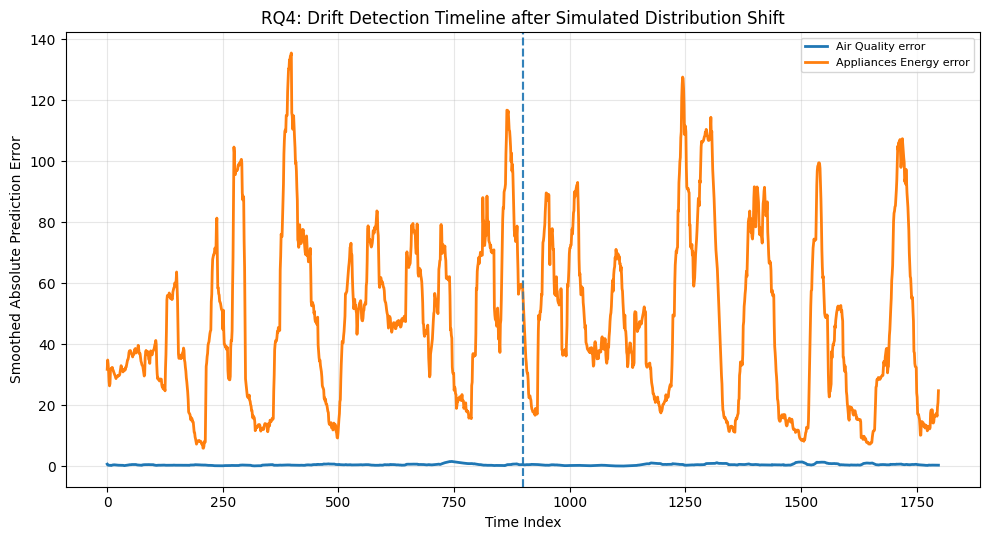

,Dataset,Target,Method,Actual Drift Index,Detected Drift Index,Detection Delay (time steps),False Positive,Accuracy Preserved (%)
0,Air Quality,CO(GT),Page-Hinkley,899,11,0.0,1,82.490750
1,Air Quality,CO(GT),KS-Test,899,248,0.0,1,82.490750
2,Air Quality,CO(GT),Rolling-Z,899,Not detected,NaN,0,82.490750
3,Appliances Energy,Appliances,Page-Hinkley,899,9,0.0,1,107.504848
4,Appliances Energy,Appliances,KS-Test,899,178,0.0,1,107.504848
5,Appliances Energy,Appliances,Rolling-Z,899,Not detected,NaN,0,107.504848


Saved table: /kaggle/working/rq4_drift_detection_outputs/Table4_RQ4_drift_detection.csv
Saved timeline values: /kaggle/working/rq4_drift_detection_outputs/Table4b_RQ4_drift_timeline_values.csv
Saved figure: /kaggle/working/rq4_drift_detection_outputs/Figure4_RQ4_drift_detection_timeline.pdf


In [1]:

# ============================================================
# Common setup for robust AI experiments on Kaggle
# Datasets:
# 1) AirQualityUCI.csv
# 2) energydata_complete.csv / KAG_energydata_complete.csv
# ============================================================

import os, glob, time, warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.impute import SimpleImputer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
from sklearn.ensemble import RandomForestRegressor, HistGradientBoostingRegressor
from sklearn.neural_network import MLPRegressor
from sklearn.inspection import permutation_importance
from scipy.stats import spearmanr, ks_2samp

RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)

def find_file(possible_names):
    if isinstance(possible_names, str):
        possible_names = [possible_names]
    for filename in possible_names:
        matches = glob.glob(f"/kaggle/input/**/{filename}", recursive=True)
        if matches:
            return matches[0]
    for filename in possible_names:
        local = f"/mnt/data/{filename}"
        if os.path.exists(local):
            return local
    print("Available files:")
    for root, dirs, files in os.walk("/kaggle/input"):
        for f in files:
            print(os.path.join(root, f))
    raise FileNotFoundError(f"Could not find any of: {possible_names}")

AIR_PATH = find_file(["AirQualityUCI.csv", "AirQualityUCI(2).csv"])
ENERGY_PATH = find_file(["energydata_complete.csv", "KAG_energydata_complete.csv"])

print("Air Quality path:", AIR_PATH)
print("Energy path:", ENERGY_PATH)

def ensure_output_dir(name):
    out = f"/kaggle/working/{name}"
    if not os.path.exists("/kaggle/working"):
        out = f"./{name}"
    os.makedirs(out, exist_ok=True)
    return out

def rmse(y_true, y_pred):
    return float(np.sqrt(mean_squared_error(y_true, y_pred)))

def load_air_quality(path=AIR_PATH):
    df = pd.read_csv(path, sep=None, engine="python")
    df = df.dropna(axis=1, how="all").dropna(axis=0, how="all")
    df = df.loc[:, ~df.columns.astype(str).str.contains("^Unnamed")]
    if "Date" in df.columns and "Time" in df.columns:
        df["datetime"] = pd.to_datetime(df["Date"].astype(str) + " " + df["Time"].astype(str), errors="coerce", dayfirst=True)
        df = df.sort_values("datetime").drop(columns=["Date", "Time"])
    for c in df.columns:
        if df[c].dtype == "object":
            df[c] = pd.to_numeric(df[c].astype(str).str.replace(",", ".", regex=False), errors="coerce")
    df = df.replace(-200, np.nan)
    numeric = df.select_dtypes(include=[np.number]).copy()
    numeric = numeric.dropna(axis=1, thresh=max(1, int(0.6 * len(numeric))))
    numeric = numeric.interpolate(limit_direction="both").ffill().bfill()
    return numeric

def load_energy(path=ENERGY_PATH):
    df = pd.read_csv(path)
    df = df.dropna(axis=1, how="all").dropna(axis=0, how="all")
    df = df.loc[:, ~df.columns.astype(str).str.contains("^Unnamed")]
    if "date" in df.columns:
        df["date"] = pd.to_datetime(df["date"], errors="coerce")
        df = df.sort_values("date").drop(columns=["date"])
    for c in df.columns:
        if df[c].dtype == "object":
            df[c] = pd.to_numeric(df[c], errors="coerce")
    numeric = df.select_dtypes(include=[np.number]).copy()
    numeric = numeric.replace([np.inf, -np.inf], np.nan)
    numeric = numeric.interpolate(limit_direction="both").ffill().bfill()
    return numeric

def make_supervised(df, target=None, lag=3, max_rows=6000):
    df = df.copy()
    if len(df) > max_rows:
        df = df.iloc[:max_rows].copy()
    if target is None:
        target = df.columns[0]
    for l in range(1, lag + 1):
        for c in df.columns:
            df[f"{c}_lag{l}"] = df[c].shift(l)
    df["target_next"] = df[target].shift(-1)
    df = df.dropna()
    X = df.drop(columns=["target_next"])
    y = df["target_next"]
    return X, y, target

def prepare_datasets(max_rows=6000, lag=3):
    air = load_air_quality()
    energy = load_energy()
    air_target = next((c for c in ["CO(GT)", "NO2(GT)", "C6H6(GT)", "T"] if c in air.columns), air.columns[0])
    energy_target = "Appliances" if "Appliances" in energy.columns else energy.columns[0]
    X_air, y_air, t_air = make_supervised(air, target=air_target, lag=lag, max_rows=max_rows)
    X_energy, y_energy, t_energy = make_supervised(energy, target=energy_target, lag=lag, max_rows=max_rows)
    return {"Air Quality": (X_air, y_air, t_air), "Appliances Energy": (X_energy, y_energy, t_energy)}

def train_test_time_split(X, y, train_frac=0.7):
    split = int(len(X) * train_frac)
    return X.iloc[:split], X.iloc[split:], y.iloc[:split], y.iloc[split:]

def build_models():
    return {
        "Random Forest": Pipeline([("imputer", SimpleImputer(strategy="median")), ("model", RandomForestRegressor(n_estimators=120, max_depth=12, random_state=RANDOM_STATE, n_jobs=-1))]),
        "HistGradientBoosting": Pipeline([("imputer", SimpleImputer(strategy="median")), ("model", HistGradientBoostingRegressor(max_iter=200, learning_rate=0.05, random_state=RANDOM_STATE))]),
        "MLP": Pipeline([("imputer", SimpleImputer(strategy="median")), ("scaler", StandardScaler()), ("model", MLPRegressor(hidden_layer_sizes=(64, 32), max_iter=300, random_state=RANDOM_STATE))])
    }

def corrupt_missing(X, rate):
    Xc = X.copy()
    if rate <= 0:
        return Xc
    rng = np.random.default_rng(RANDOM_STATE + int(rate * 1000))
    mask = rng.random(Xc.shape) < rate
    return Xc.mask(mask)

def corrupt_noise(X, noise_level):
    Xc = X.copy()
    if noise_level <= 0:
        return Xc
    std = Xc.std(numeric_only=True).replace(0, 1).values
    rng = np.random.default_rng(RANDOM_STATE + int(noise_level * 1000))
    noise = rng.normal(0, noise_level, size=Xc.shape) * std
    return Xc + noise

def evaluate_regression(y_true, pred):
    return {"RMSE": rmse(y_true, pred), "MAE": float(mean_absolute_error(y_true, pred)), "R2": float(r2_score(y_true, pred))}

# ============================================================
# RQ4: Drift Detection
# ============================================================
OUT = ensure_output_dir("rq4_drift_detection_outputs")
datasets = prepare_datasets(max_rows=6000, lag=3)
def page_hinkley_detection(errors, delta=0.005, threshold=3.0):
    mean = 0.0; cum_sum = 0.0; min_cum_sum = 0.0
    for i, e in enumerate(errors):
        mean = mean + (e - mean) / (i + 1)
        cum_sum += e - mean - delta
        min_cum_sum = min(min_cum_sum, cum_sum)
        if cum_sum - min_cum_sum > threshold * np.std(errors[:max(i+1, 2)]):
            return i
    return None
def ks_window_detection(errors, window=100, alpha=0.01):
    for i in range(window * 2, len(errors), 10):
        _, p = ks_2samp(errors[i - 2*window:i - window], errors[i - window:i])
        if p < alpha:
            return i
    return None
def rolling_z_detection(errors, baseline_end, z_thresh=3.0, window=30):
    baseline = errors[:baseline_end]
    mu, sigma = np.mean(baseline), np.std(baseline) + 1e-9
    for i in range(baseline_end, len(errors) - window):
        cur = np.mean(errors[i:i+window])
        if abs((cur - mu) / sigma) > z_thresh:
            return i
    return None
rows = []
timeline_records = []
for dataset_name, (X, y, target) in datasets.items():
    print(f"\nDataset: {dataset_name}, Target: {target}, Shape: {X.shape}")
    X_train, X_test, y_train, y_test = train_test_time_split(X, y)
    model = Pipeline([("imputer", SimpleImputer(strategy="median")), ("model", RandomForestRegressor(n_estimators=120, max_depth=12, random_state=RANDOM_STATE, n_jobs=-1))])
    model.fit(X_train, y_train)
    X_shifted = X_test.copy()
    drift_point = len(X_shifted) // 2
    top_features = X_shifted.var().sort_values(ascending=False).head(5).index
    X_shifted.loc[X_shifted.index[drift_point:], top_features] = X_shifted.loc[X_shifted.index[drift_point:], top_features] * 1.20
    pred = model.predict(X_shifted)
    errors = np.abs(np.asarray(y_test) - pred)
    baseline_rmse = rmse(y_test.iloc[:drift_point], pred[:drift_point])
    after_rmse = rmse(y_test.iloc[drift_point:], pred[drift_point:])
    methods = {"Page-Hinkley": page_hinkley_detection(errors), "KS-Test": ks_window_detection(errors, window=max(50, len(errors)//20)), "Rolling-Z": rolling_z_detection(errors, baseline_end=max(50, drift_point//2))}
    for method, detected in methods.items():
        delay = np.nan if detected is None else max(0, detected - drift_point)
        false_positive = 0 if detected is None or detected >= drift_point else 1
        rows.append({"Dataset": dataset_name, "Target": target, "Method": method, "Actual Drift Index": drift_point, "Detected Drift Index": detected if detected is not None else "Not detected", "Detection Delay (time steps)": delay, "False Positive": false_positive, "Accuracy Preserved (%)": max(0, 100 * baseline_rmse / after_rmse)})
    for i, e in enumerate(errors):
        timeline_records.append({"Dataset": dataset_name, "Time Index": i, "Absolute Error": e, "Actual Drift Index": drift_point})
table = pd.DataFrame(rows)
timeline = pd.DataFrame(timeline_records)
table_path = f"{OUT}/Table4_RQ4_drift_detection.csv"
timeline_path = f"{OUT}/Table4b_RQ4_drift_timeline_values.csv"
table.to_csv(table_path, index=False)
timeline.to_csv(timeline_path, index=False)
plt.figure(figsize=(10, 5.5))
for dataset_name in timeline["Dataset"].unique():
    subset = timeline[timeline["Dataset"] == dataset_name].reset_index(drop=True)
    smooth = subset["Absolute Error"].rolling(25, min_periods=1).mean()
    plt.plot(subset["Time Index"], smooth, linewidth=2, label=f"{dataset_name} error")
    plt.axvline(int(subset["Actual Drift Index"].iloc[0]), linestyle="--", alpha=0.7)
plt.xlabel("Time Index")
plt.ylabel("Smoothed Absolute Prediction Error")
plt.title("RQ4: Drift Detection Timeline after Simulated Distribution Shift")
plt.grid(True, alpha=0.3)
plt.legend(fontsize=8)
plt.tight_layout()
fig_path = f"{OUT}/Figure4_RQ4_drift_detection_timeline.pdf"
plt.savefig(fig_path)
plt.show()
display(table)
print("Saved table:", table_path)
print("Saved timeline values:", timeline_path)
print("Saved figure:", fig_path)
